<a href="https://colab.research.google.com/github/mvaraujo1977/TechCahllenge_Tireoide/blob/Filomeno/model_tireoide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Início do trabalho** <br>
Construção de um modelo de Machine Learning para identificação de hipotireoidismo<br>
Carregando e visualizando o Dataset

In [1]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('/content/hypothyroid.data', header=None, na_values='?')

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {df.shape}")
print(df.head())

Dataset carregado com sucesso!
Formato do dataset: (3163, 26)
            0     1  2  3  4  5  6  7  8  9   ... 16   17 18    19 20    21  \
0  hypothyroid  72.0  M  f  f  f  f  f  f  f  ...  y  0.6  y  15.0  y  1.48   
1  hypothyroid  15.0  F  t  f  f  f  f  f  f  ...  y  1.7  y  19.0  y  1.13   
2  hypothyroid  24.0  M  f  f  f  f  f  f  f  ...  y  0.2  y   4.0  y  1.00   
3  hypothyroid  24.0  F  f  f  f  f  f  f  f  ...  y  0.4  y   6.0  y  1.04   
4  hypothyroid  77.0  M  f  f  f  f  f  f  f  ...  y  1.2  y  57.0  y  1.28   

  22    23 24  25  
0  y  10.0  n NaN  
1  y  17.0  n NaN  
2  y   0.0  n NaN  
3  y   6.0  n NaN  
4  y  44.0  n NaN  

[5 rows x 26 columns]


**Ajustes no Dataset**<br>
Este Dataset tem um arquivo separado com o nome das colunas, assim faremos um pequeno ajuste para colocar os nomes das colunas corretamente no Dataset

In [10]:
import re
import os

names_file = 'hypothyroid.names'

column_names = []

if os.path.exists(names_file):
    with open(names_file, 'r') as f:
        lines = f.readlines()

    # Tenta encontrar a linha que define as classes (primeira coluna)
    # No dataset hypothyroid, a primeira coluna geralmente é o alvo
    column_names.append('target')

    # Procura por padrões como 'nome_da_coluna: tipo.' no arquivo .names
    for line in lines:
        match = re.search(r'^([a-zA-Z0-9_ \-]+):', line)
        if match:
            col_name = match.group(1).strip().replace(' ', '_')
            if col_name not in column_names:
                column_names.append(col_name)

# Se conseguimos extrair nomes, aplicamos ao dataframe
if len(column_names) == len(df.columns):
    df.columns = column_names
    print("Nomes das colunas aplicados com sucesso!")

display(df.head())
df.describe()
display(df.tail())

,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,30.0,y,0.6,y,15.0,y,1.48,y,10.0
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,145.0,y,1.7,y,19.0,y,1.13,y,17.0
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.0,y,0.2,y,4.0,y,1.00,y,0.0
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,430.0,y,0.4,y,6.0,y,1.04,y,6.0
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,7.3,y,1.2,y,57.0,y,1.28,y,44.0


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI
3158,negative,58.0,F,f,f,f,f,f,f,f,...,y,5.8,y,1.7,y,86.0,y,0.91,y,95.0
3159,negative,29.0,F,f,f,f,f,f,f,f,...,y,0.8,y,1.8,y,99.0,y,1.01,y,98.0
3160,negative,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,0.6,y,71.0,y,0.68,y,104.0
3161,negative,74.0,F,f,f,f,f,f,f,f,...,y,1.3,y,0.1,y,65.0,y,0.48,y,137.0
3162,negative,56.0,F,t,f,f,f,f,f,f,...,y,0.0,y,1.8,y,139.0,y,0.97,y,143.0


In [3]:
from google.colab import files

# Nome do arquivo de saída
output_filename = 'hypothyroid_final.csv'

# Salva o dataframe como CSV
df.to_csv(output_filename, index=False)

print(f'Arquivo {output_filename} gerado com sucesso!')

Arquivo hypothyroid_final.csv gerado com sucesso!


**Target**<BR>
Para poder-mos ter uma noção melhor dos dados é sempre interessante criar uma visualização dos dados com relação ao nosso Target que é descobrir a condição de Hipotireoidismo, com isso teremos uma noção melhor de quantos dados temos em cada target para podermos pensar na divisão de dados para treinamento e teste.

In [4]:
df.groupby('target').describe()

age                                                      \
              count       mean        std  min    25%   50%   75%   max   
target                                                                    
hypothyroid   136.0  54.294118  19.809507  5.0  40.75  59.5  71.0  88.0   
negative     2581.0  50.988764  19.256617  1.0  34.00  54.0  67.0  98.0   

                TSH             ...    FTI           TBG             \
              count       mean  ...    75%    max  count       mean   
target                          ...                                   
hypothyroid   150.0  63.638667  ...   51.0  133.0    3.0  30.000000   
negative     2545.0   2.521481  ...  131.0  881.0  257.0  31.298054   

                                                       
                   std   min   25%   50%   75%    max  
target                                                 
hypothyroid   3.464102  28.0  28.0  28.0  31.0   34.0  
negative     19.334046   0.0  21.0  28.0  34.0  122.0  

[2 rows x 56 columns]

**Descoberta e Visualização de Inconcistências**<BR>
É de extrama importância verificarmos se o Dataset está completo e sem inconcistências assim podemos regulariza-las antes do treinamento.

In [5]:
#Verificando inconsistências
df.isnull().sum()

,0
target,0
age,446
sex,73
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_medication,0
thyroid_surgery,0
query_hypothyroid,0
query_hyperthyroid,0
pregnant,0


**Visualização gráfica de inconcistências**

<Axes: >

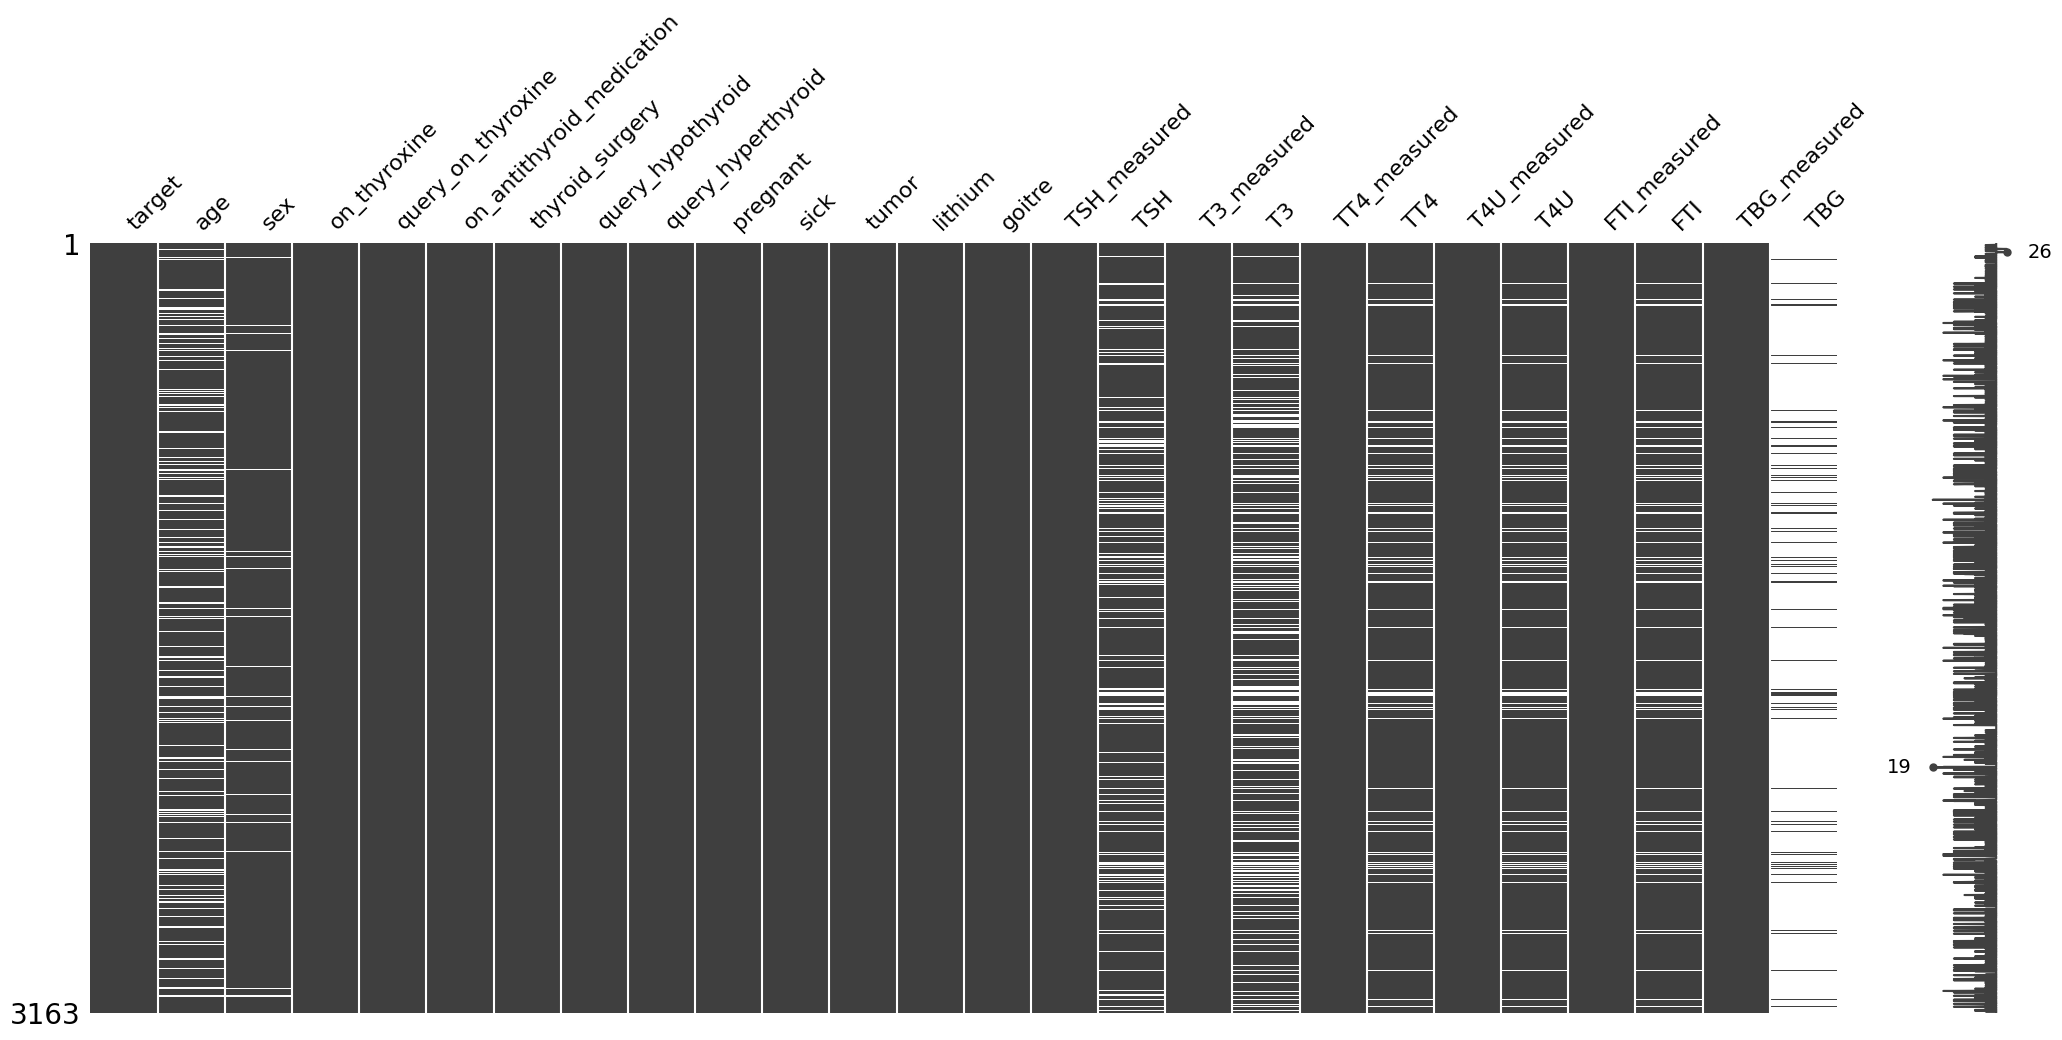

In [6]:
import missingno as msno
msno.matrix(df)

**Tratamento de Valores Nulos** <br>
Para coluna 'sex', a imputação será feita NA (Not Available - não informado) (para que o modelo não fique tendencioso com relação ao genero). Para as colunas numéricas ('age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI'), a imputação será realizada com a mediana, que é mais robusta a outliers do que a média.<br>
Neste dataset específico, a importância da TBG é baixa, por dois motivos principais:


1.   Alta taxa de ausência: Após analisar os dados, notei que a coluna TBG possui mais de 90% dos dados estão faltando.

2.   O dataset já possui as colunas T4U (Capacidade de ligação da tiroxina) e FTI (Índice de Tiroxina Livre). O FTI é calculado justamente para ajustar o valor do T4 em relação à capacidade de ligação das proteínas (como a TBG). Portanto, a informação clínica relevante que a TBG traria já está indiretamente representada em outras colunas.

Assim a melhor forma de tratar as colunas TGB e TBG_measured é simplesmente dropa-las do dataset

In [7]:
#. Imputar 'NA' para a coluna 'sex'
if 'sex' in df.columns:
    df['sex'] = df['sex'].fillna('NA')

#. Imputar colunas numéricas com a mediana
numeric_cols_to_impute = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
for col in numeric_cols_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

#. Drop das colunas TGB e TBG_measured
df.drop(columns=['TBG', 'TBG_measured'], inplace=True)

print(df.isnull().sum())

target                       0
age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
thyroid_surgery              0
query_hypothyroid            0
query_hyperthyroid           0
pregnant                     0
sick                         0
tumor                        0
lithium                      0
goitre                       0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
dtype: int64


Verificar os tipos utilizados nas colunas para transforma-las utilizando LabelEncoder para poder-mos gerar a Matriz de Correlação

In [17]:
df.dtypes

,0
target,object
age,float64
sex,object
on_thyroxine,object
query_on_thyroxine,object
on_antithyroid_medication,object
thyroid_surgery,object
query_hypothyroid,object
query_hyperthyroid,object
pregnant,object


**Matriz de Correlação**<br>
Criando uma matriz de correlação com <u>heatmap</u> para entender a correlação entre as colunas e poder descobrir quais colunas tem as melhores correlações ao nosso target e as correlações entre colunas

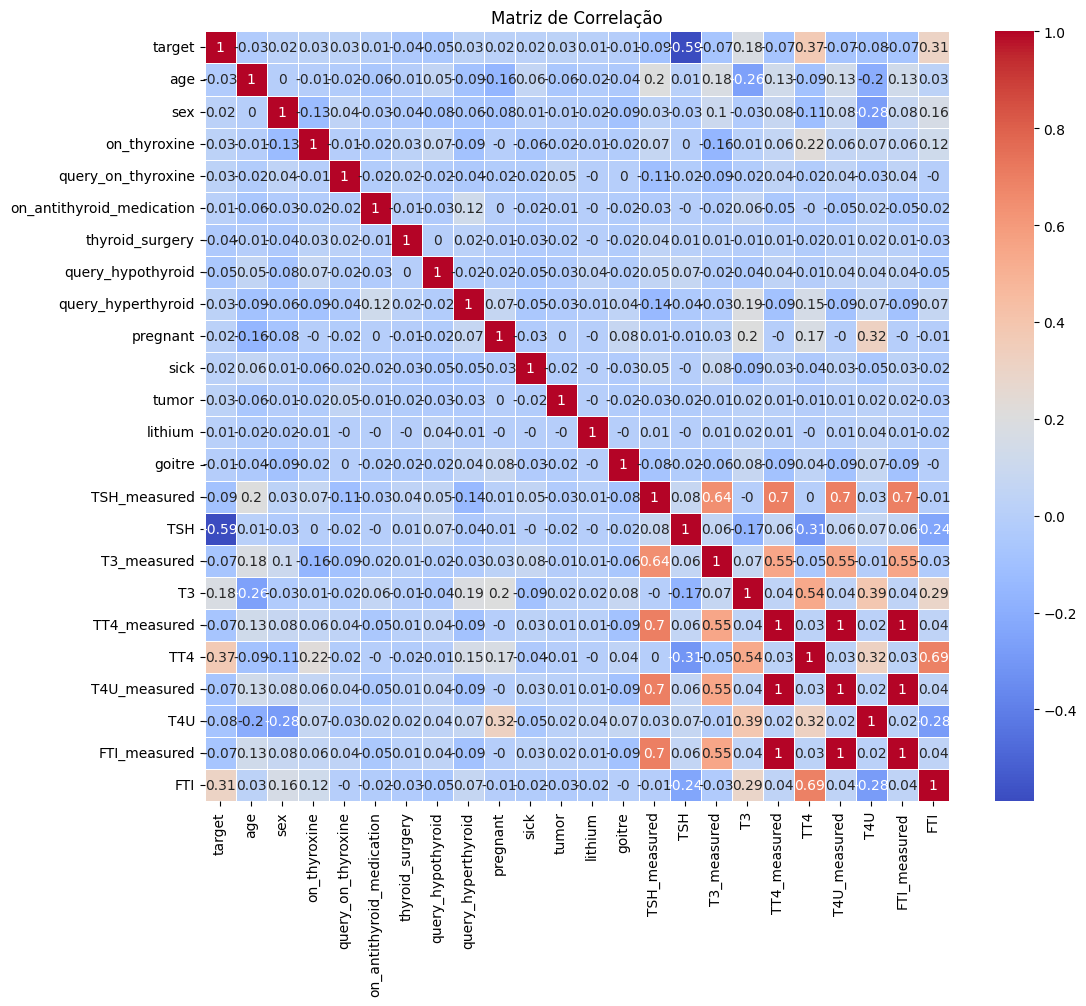

In [16]:
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


colunas = ["target", "sex", "on_thyroxine", "query_on_thyroxine",	"on_antithyroid_medication",	"thyroid_surgery",
           "query_hypothyroid",	"query_hyperthyroid",	"pregnant", "sick", "tumor", "lithium", "goitre",
           "TSH_measured", "T3_measured", "TT4_measured", "T4U_measured", "FTI_measured"]

label_encoder = LabelEncoder()
df_correlation = df.copy()
for col in colunas:
    if col in df_correlation.columns:
        df_correlation[col] = label_encoder.fit_transform(df_correlation[col])

# Calcular a matriz de correlação
# Selecionando apenas colunas numéricas para a correlação
correlation_matriz = df_correlation.select_dtypes(include=['number']).corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sb.heatmap(data=correlation_matriz, annot=True, cmap='coolwarm', linewidths=0.5, ax=ax)
plt.title('Matriz de Correlação')
plt.show()